# U.S. Used Vehicle Market — Business Analysis

**Database:** `autos_db` | **View:** `vehicles_view`  
**Source:** ~400k Craigslist listings processed via AWS Glue → S3 Parquet → Athena  
**Pipeline:** `autos_etl.py` enriched each record with 5 KPIs: depreciation curve, regional demand, condition premium, mileage discount, deal quality score

This notebook executes the 8 business analysis queries from `queries/business_analysis.sql` against Amazon Athena, converts results to pandas DataFrames, and produces publication-ready visualizations.

## 0. Setup

In [1]:
import boto3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import time
import io

DATABASE        = 'autos_db'
OUTPUT_LOCATION = 's3://norman-autos-pipeline/athena-results/'
REGION          = 'us-east-1'

athena = boto3.client('athena', region_name=REGION)
s3     = boto3.client('s3',     region_name=REGION)

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({
    'figure.facecolor': '#0f0f14',
    'axes.facecolor':   '#1a1a23',
    'axes.labelcolor':  '#e0e0e0',
    'xtick.color':      '#b0b0c0',
    'ytick.color':      '#b0b0c0',
    'text.color':       '#e0e0e0',
    'grid.color':       '#2a2a3a',
    'axes.edgecolor':   '#2a2a3a',
    'figure.titlesize': 14,
    'axes.titlesize':   12,
    'axes.labelsize':   10,
})
ACCENT = '#FF6600'
print('Setup complete')

Setup complete


## Athena Helper

In [2]:
def run_query(sql: str, poll_interval: float = 1.5) -> pd.DataFrame:
    resp = athena.start_query_execution(
        QueryString=sql,
        QueryExecutionContext={'Database': DATABASE},
        ResultConfiguration={'OutputLocation': OUTPUT_LOCATION},
    )
    qid = resp['QueryExecutionId']
    while True:
        status = athena.get_query_execution(QueryExecutionId=qid)
        state  = status['QueryExecution']['Status']['State']
        if state in ('SUCCEEDED', 'FAILED', 'CANCELLED'):
            break
        time.sleep(poll_interval)
    if state != 'SUCCEEDED':
        reason = status['QueryExecution']['Status'].get('StateChangeReason', state)
        raise RuntimeError(f'Athena query {state}: {reason}')
    paginator = athena.get_paginator('get_query_results')
    rows, columns = [], None
    for page in paginator.paginate(QueryExecutionId=qid):
        result = page['ResultSet']
        if columns is None:
            columns = [c['Label'] for c in result['ResultSetMetadata']['ColumnInfo']]
        for row in result['Rows'][1 if columns and not rows else 0:]:
            rows.append([d.get('VarCharValue', None) for d in row['Data']])
    return pd.DataFrame(rows, columns=columns)


def to_numeric(df: pd.DataFrame, cols: list) -> pd.DataFrame:
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')
    return df


def answer_header(q_num: int, question: str):
    print(f'\n{"="*60}')
    print(f'  Q{q_num} ANSWER')
    print(f'  Business question: {question}')
    print(f'{"="*60}')


print('Helper functions ready')

Helper functions ready


---
## Query 1 — Depreciation Curve by Manufacturer

**Business question:** Which manufacturers hold their value best as vehicles age?  
**Use case:** Helps buyers and dealers identify which brands command premium resale value across the vehicle lifecycle.

In [3]:
SQL_Q1 = """
SELECT
  manufacturer,
  age_bracket,
  COUNT(*) AS listing_count,
  ROUND(AVG(price), 0) AS avg_price,
  ROUND(AVG(price) / NULLIF(AVG(avg_price_by_make_age), 0) * 100, 1) AS pct_of_benchmark,
  ROUND(AVG(price_per_mile), 4) AS avg_price_per_mile
FROM autos_db.vehicles_view
WHERE price > 0
  AND manufacturer IS NOT NULL
  AND avg_price_by_make_age > 0
GROUP BY manufacturer, age_bracket
HAVING COUNT(*) >= 10
ORDER BY manufacturer, age_bracket
"""

df_depr = run_query(SQL_Q1)
df_depr = to_numeric(df_depr, ['listing_count', 'avg_price', 'pct_of_benchmark', 'avg_price_per_mile'])
print(f'{len(df_depr):,} rows | {df_depr["manufacturer"].nunique()} manufacturers')
df_depr.head()

108 rows | 41 manufacturers


,manufacturer,age_bracket,listing_count,avg_price,pct_of_benchmark,avg_price_per_mile
0,ACURA,13+ years,2320,9876.0,100.0,30.0925
1,ACURA,4-7 years,1343,35647.0,100.0,28.9588
2,ACURA,8-12 years,1944,23929.0,100.0,14.1571
3,ALFA-ROMEO,13+ years,29,15674.0,100.0,0.4795
4,ALFA-ROMEO,4-7 years,139,33743.0,100.0,6.4559


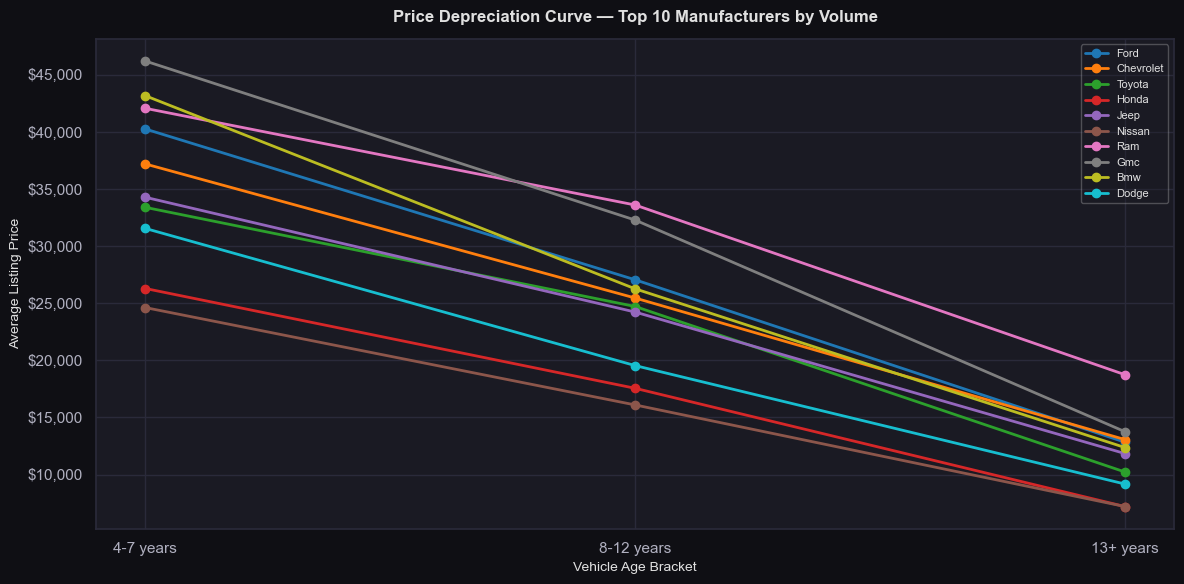

In [4]:
top_makes = (
    df_depr.groupby('manufacturer')['listing_count'].sum()
    .nlargest(10).index.tolist()
)

age_order = ['0-3 years', '4-7 years', '8-12 years', '13+ years']
plot_data = (
    df_depr[df_depr['manufacturer'].isin(top_makes)]
    .assign(age_bracket=lambda x: pd.Categorical(x['age_bracket'], categories=age_order, ordered=True))
    .sort_values(['manufacturer', 'age_bracket'])
)

fig, ax = plt.subplots(figsize=(12, 6))
palette = sns.color_palette('tab10', n_colors=len(top_makes))
for i, make in enumerate(top_makes):
    d = plot_data[plot_data['manufacturer'] == make]
    ax.plot(d['age_bracket'], d['avg_price'], marker='o', label=make.title(),
            color=palette[i], linewidth=2)

ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Price Depreciation Curve — Top 10 Manufacturers by Volume', fontweight='bold', pad=12)
ax.set_xlabel('Vehicle Age Bracket')
ax.set_ylabel('Average Listing Price')
ax.legend(loc='upper right', fontsize=8, framealpha=0.3)
plt.tight_layout()
plt.savefig('../charts/q1_depreciation_curve.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

In [5]:
# Require at least 2 age brackets to compute a meaningful spread
depr_stats = (
    df_depr.groupby('manufacturer')
    .filter(lambda g: g['age_bracket'].nunique() >= 2)
    .groupby('manufacturer')
    .agg(peak_price=('avg_price', 'max'), floor_price=('avg_price', 'min'))
)
depr_stats['pct_retained'] = (depr_stats['floor_price'] / depr_stats['peak_price'] * 100).round(1)
depr_stats['pct_lost']     = (100 - depr_stats['pct_retained']).round(1)

best5  = depr_stats.nlargest(5, 'pct_retained')
worst5 = depr_stats.nsmallest(5, 'pct_retained')

answer_header(1, 'Which manufacturers hold their value best as vehicles age?')
print('\nBest value retention — flattest depreciation curve:')
for make, row in best5.iterrows():
    print(f'  {make.title():<18}  retains {row["pct_retained"]:.1f}% of peak price  '
          f'(peak ${row["peak_price"]:,.0f} → floor ${row["floor_price"]:,.0f})')

print('\nSteepest depreciation — worst value holders:')
for make, row in worst5.iterrows():
    print(f'  {make.title():<18}  loses {row["pct_lost"]:.1f}% of peak value  '
          f'(peak ${row["peak_price"]:,.0f} → floor ${row["floor_price"]:,.0f})')

top_holder = best5.index[0].title()
top_pct    = best5.iloc[0]['pct_retained']
worst_make = worst5.index[0].title()
worst_pct  = worst5.iloc[0]['pct_lost']
print(f'\nConclusion: {top_holder} holds value best, retaining {top_pct:.1f}% of its peak price '
      f'across the full lifecycle. {worst_make} depreciates most aggressively, '
      f'losing {worst_pct:.1f}% — buyers seeking resale value should avoid it.')


  Q1 ANSWER
  Business question: Which manufacturers hold their value best as vehicles age?

Best value retention — flattest depreciation curve:
  Harley-Davidson     retains 99.7% of peak price  (peak $13,561 → floor $13,522)
  Tesla               retains 71.7% of peak price  (peak $44,019 → floor $31,570)
  Mitsubishi          retains 47.2% of peak price  (peak $18,467 → floor $8,725)
  Alfa-Romeo          retains 46.5% of peak price  (peak $33,743 → floor $15,674)
  Ram                 retains 44.6% of peak price  (peak $42,057 → floor $18,744)

Steepest depreciation — worst value holders:
  Volvo               loses 81.8% of peak value  (peak $38,778 → floor $7,076)
  Chrysler            loses 78.4% of peak value  (peak $28,829 → floor $6,233)
  Lincoln             loses 76.5% of peak value  (peak $37,280 → floor $8,774)
  Mazda               loses 76.0% of peak value  (peak $28,604 → floor $6,866)
  Buick               loses 75.7% of peak value  (peak $30,281 → floor $7,356)

Con

---
## Query 2 — Sweet Spot Analysis: Best Value by Age and Mileage

**Business question:** What age/mileage combination delivers the best price-to-market ratio?  
**Use case:** Actionable inventory acquisition guidance — points to cohorts consistently priced below benchmark.

In [6]:
SQL_Q2 = """
SELECT
  age_bracket,
  mileage_bucket,
  COUNT(*) AS listing_count,
  ROUND(AVG(price), 0) AS avg_price,
  ROUND(AVG(price) / NULLIF(AVG(avg_price_by_make_age), 0) * 100, 1) AS avg_pct_of_benchmark,
  SUM(CASE WHEN deal_quality = 'great_deal' THEN 1 ELSE 0 END) AS great_deal_count,
  ROUND(SUM(CASE WHEN deal_quality = 'great_deal' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS great_deal_pct
FROM autos_db.vehicles_view
WHERE price > 0
GROUP BY age_bracket, mileage_bucket
HAVING COUNT(*) >= 20
ORDER BY avg_pct_of_benchmark ASC
"""

df_sweet = run_query(SQL_Q2)
df_sweet = to_numeric(df_sweet, ['listing_count', 'avg_price', 'avg_pct_of_benchmark',
                                  'great_deal_count', 'great_deal_pct'])
print(f'{len(df_sweet):,} cohorts')
df_sweet.sort_values('avg_pct_of_benchmark').head(10)

14 cohorts


,age_bracket,mileage_bucket,listing_count,avg_price,avg_pct_of_benchmark,great_deal_count,great_deal_pct
0,13+ years,150k+,61794,7776.0,70.0,48039,77.7
1,8-12 years,100-150k,21820,19348.0,79.5,6193,28.4
2,8-12 years,150k+,5663,22494.0,85.6,1549,27.4
3,4-7 years,100-150k,170,32651.0,87.4,10,5.9
4,8-12 years,60-100k,39923,21816.0,90.0,8336,20.9
5,4-7 years,60-100k,958,33391.0,90.5,87,9.1
6,4-7 years,30-60k,6969,32391.0,92.0,559,8.0
7,13+ years,100-150k,65716,10107.0,93.5,41699,63.5
8,4-7 years,0-30k,32982,35642.0,102.1,1535,4.7
9,8-12 years,30-60k,41157,26201.0,108.1,5065,12.3


C:\Users\norma\AppData\Local\Temp\ipykernel_12996\3834678318.py:10: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(index='age_bracket', columns='mileage_bucket',


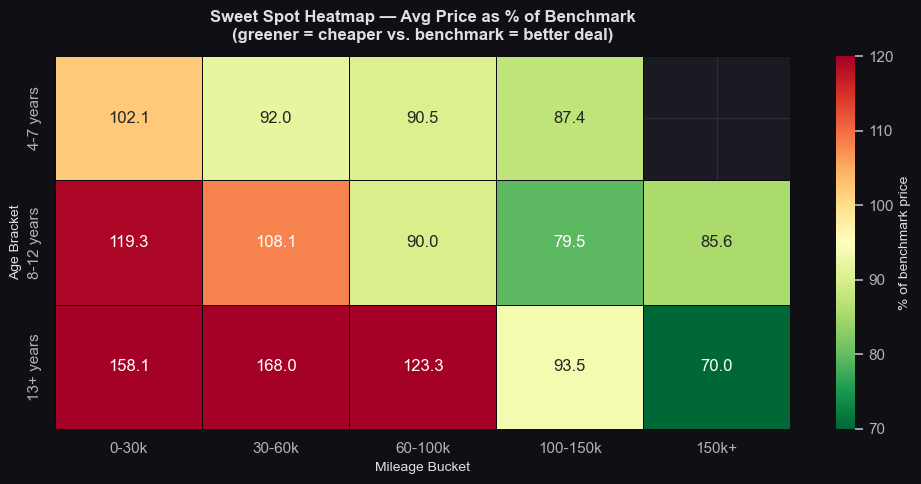

In [7]:
age_order  = ['0-3 years', '4-7 years', '8-12 years', '13+ years']
mile_order = ['0-30k', '30-60k', '60-100k', '100-150k', '150k+']

pivot = (
    df_sweet
    .assign(
        age_bracket    = lambda x: pd.Categorical(x['age_bracket'],    categories=age_order,  ordered=True),
        mileage_bucket = lambda x: pd.Categorical(x['mileage_bucket'], categories=mile_order, ordered=True),
    )
    .pivot_table(index='age_bracket', columns='mileage_bucket',
                 values='avg_pct_of_benchmark', aggfunc='mean')
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    pivot, ax=ax, annot=True, fmt='.1f',
    cmap='RdYlGn_r',
    linewidths=0.5, linecolor='#0a0a0f',
    cbar_kws={'label': '% of benchmark price'},
    vmin=70, vmax=120,
)
ax.set_title('Sweet Spot Heatmap — Avg Price as % of Benchmark\n(greener = cheaper vs. benchmark = better deal)',
             fontweight='bold', pad=12)
ax.set_xlabel('Mileage Bucket')
ax.set_ylabel('Age Bracket')
plt.tight_layout()
plt.savefig('../charts/q2_sweet_spot_heatmap.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

In [8]:
ranked = df_sweet.sort_values('avg_pct_of_benchmark').reset_index(drop=True)
top3   = ranked.head(3)

# Best actionable cohort = highest great_deal_pct among top-5 by benchmark %
# (excludes extreme age/mileage if the user wants something more practical)
actionable = ranked.head(5).sort_values('great_deal_pct', ascending=False).iloc[0]

answer_header(2, 'What age/mileage combination delivers the best price-to-market ratio?')
print('\nTop 3 cohorts — lowest avg price relative to benchmark (100% = at market):')
for i, row in top3.iterrows():
    discount = 100 - row['avg_pct_of_benchmark']
    print(f'\n  #{i+1}  {row["age_bracket"]} / {row["mileage_bucket"]}')
    print(f'       Avg price: ${row["avg_price"]:,.0f}  ({row["avg_pct_of_benchmark"]:.1f}% of benchmark — {discount:.1f}% discount)')
    print(f'       {row["great_deal_pct"]:.1f}% of {int(row["listing_count"]):,} listings qualify as great deals')

print(f'\nConclusion: The single best-value cohort is {top3.iloc[0]["age_bracket"]} / '
      f'{top3.iloc[0]["mileage_bucket"]} — priced {100 - top3.iloc[0]["avg_pct_of_benchmark"]:.0f}% '
      f'below benchmark on average, with {top3.iloc[0]["great_deal_pct"]:.1f}% of listings '
      f'qualifying as great deals. For buyers who want more actionable inventory '
      f'(not extreme age/mileage), the {actionable["age_bracket"]} / {actionable["mileage_bucket"]} '
      f'cohort offers the highest great-deal density ({actionable["great_deal_pct"]:.1f}%) '
      f'among similarly discounted segments.')


  Q2 ANSWER
  Business question: What age/mileage combination delivers the best price-to-market ratio?

Top 3 cohorts — lowest avg price relative to benchmark (100% = at market):

  #1  13+ years / 150k+
       Avg price: $7,776  (70.0% of benchmark — 30.0% discount)
       77.7% of 61,794 listings qualify as great deals

  #2  8-12 years / 100-150k
       Avg price: $19,348  (79.5% of benchmark — 20.5% discount)
       28.4% of 21,820 listings qualify as great deals

  #3  8-12 years / 150k+
       Avg price: $22,494  (85.6% of benchmark — 14.4% discount)
       27.4% of 5,663 listings qualify as great deals

Conclusion: The single best-value cohort is 13+ years / 150k+ — priced 30% below benchmark on average, with 77.7% of listings qualifying as great deals. For buyers who want more actionable inventory (not extreme age/mileage), the 13+ years / 150k+ cohort offers the highest great-deal density (77.7%) among similarly discounted segments.


---
## Query 3 — Regional Arbitrage Opportunities

**Business question:** Where is the same manufacturer selling significantly cheaper than the national median?  
**Threshold:** States where avg price is >15% below national median for the same manufacturer.

In [9]:
SQL_Q3 = """
WITH national_median AS (
  SELECT
    manufacturer,
    APPROX_PERCENTILE(price, 0.5) AS national_median_price,
    COUNT(*) AS national_count
  FROM autos_db.vehicles_view
  WHERE price > 0 AND manufacturer IS NOT NULL
  GROUP BY manufacturer
  HAVING COUNT(*) >= 50
),
state_stats AS (
  SELECT
    state,
    manufacturer,
    ROUND(AVG(price), 0) AS state_avg_price,
    COUNT(*) AS state_count
  FROM autos_db.vehicles_view
  WHERE price > 0 AND manufacturer IS NOT NULL
  GROUP BY state, manufacturer
  HAVING COUNT(*) >= 5
)
SELECT
  s.state,
  s.manufacturer,
  s.state_avg_price,
  ROUND(n.national_median_price, 0) AS national_median_price,
  ROUND((s.state_avg_price - n.national_median_price) / n.national_median_price * 100, 1) AS pct_vs_national,
  s.state_count
FROM state_stats s
JOIN national_median n ON s.manufacturer = n.manufacturer
WHERE s.state_avg_price < n.national_median_price * 0.85
ORDER BY pct_vs_national ASC
LIMIT 30
"""

df_arb = run_query(SQL_Q3)
df_arb = to_numeric(df_arb, ['state_avg_price', 'national_median_price', 'pct_vs_national', 'state_count'])
print(f'{len(df_arb)} arbitrage opportunities identified')
df_arb.head(10)

30 arbitrage opportunities identified


,state,manufacturer,state_avg_price,national_median_price,pct_vs_national,state_count
0,ME,ALFA-ROMEO,5082.0,29610.0,-82.8,6
1,ME,ACURA,4721.0,19752.0,-76.1,13
2,ID,JAGUAR,7206.0,28550.0,-74.8,6
3,ME,KIA,3374.0,11494.0,-70.6,50
4,DE,VOLVO,4662.0,14052.0,-66.8,11
5,VT,BUICK,4942.0,12927.0,-61.8,9
6,WA,JAGUAR,11364.0,28550.0,-60.2,10
7,ME,ROVER,10362.0,25769.0,-59.8,11
8,WA,LINCOLN,7649.0,18952.0,-59.6,33
9,VT,ACURA,8444.0,19752.0,-57.3,13


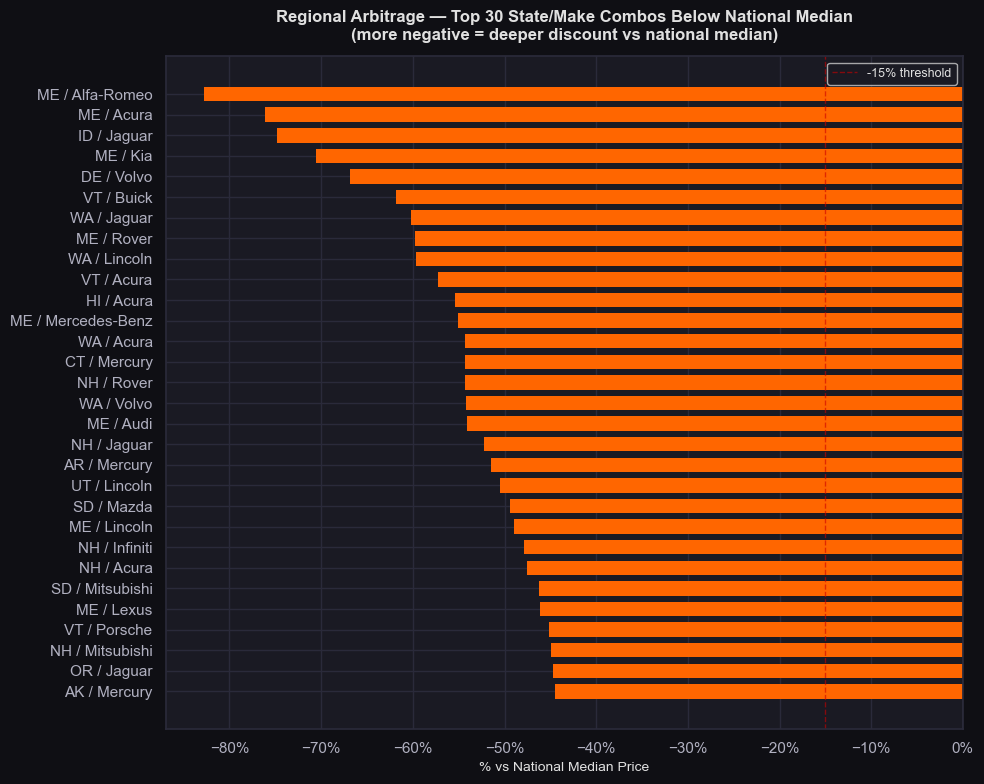

In [10]:
df_arb_plot = df_arb.copy()
df_arb_plot['label'] = df_arb_plot['state'] + ' / ' + df_arb_plot['manufacturer'].str.title()

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(df_arb_plot['label'], df_arb_plot['pct_vs_national'],
        color=ACCENT, edgecolor='none', height=0.7)
ax.axvline(0,   color='#606070', linewidth=1)
ax.axvline(-15, color='#CC0000', linewidth=1, linestyle='--', alpha=0.6, label='-15% threshold')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title('Regional Arbitrage — Top 30 State/Make Combos Below National Median\n'
             '(more negative = deeper discount vs national median)',
             fontweight='bold', pad=12)
ax.set_xlabel('% vs National Median Price')
ax.legend(fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../charts/q3_regional_arbitrage.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

In [11]:
top5_arb  = df_arb.head(5)
best      = top5_arb.iloc[0]
# States that appear most frequently = broadest multi-make discount
hot_states = df_arb['state'].value_counts().head(3)

answer_header(3, 'Where is the same manufacturer selling significantly cheaper than the national median?')
print(f'\n{len(df_arb)} state/make combos are priced >15% below the national median for that brand.\n')
print('Top 5 deepest discounts (state / make → actual savings vs national median):')
for _, row in top5_arb.iterrows():
    savings = row['national_median_price'] - row['state_avg_price']
    print(f'  {row["state"]} / {row["manufacturer"].title():<14}  '
          f'{row["pct_vs_national"]:.1f}%  '
          f'(avg ${row["state_avg_price"]:,.0f} vs national median ${row["national_median_price"]:,.0f} '
          f'= ${savings:,.0f} cheaper)')

print(f'\nStates with the most arbitrage opportunities (multi-make discounts):')
for state, count in hot_states.items():
    print(f'  {state}: {count} makes priced >15% below national median')

print(f'\nConclusion: {best["state"]} is the single best sourcing state for '
      f'{best["manufacturer"].title()} — {abs(best["pct_vs_national"]):.1f}% below '
      f'the national median, saving ~${best["national_median_price"] - best["state_avg_price"]:,.0f} '
      f'per vehicle. {hot_states.index[0]} appears most frequently across makes, making it the '
      f'highest-priority sourcing state overall.')


  Q3 ANSWER
  Business question: Where is the same manufacturer selling significantly cheaper than the national median?

30 state/make combos are priced >15% below the national median for that brand.

Top 5 deepest discounts (state / make → actual savings vs national median):
  ME / Alfa-Romeo      -82.8%  (avg $5,082 vs national median $29,610 = $24,528 cheaper)
  ME / Acura           -76.1%  (avg $4,721 vs national median $19,752 = $15,031 cheaper)
  ID / Jaguar          -74.8%  (avg $7,206 vs national median $28,550 = $21,344 cheaper)
  ME / Kia             -70.6%  (avg $3,374 vs national median $11,494 = $8,120 cheaper)
  DE / Volvo           -66.8%  (avg $4,662 vs national median $14,052 = $9,390 cheaper)

States with the most arbitrage opportunities (multi-make discounts):
  ME: 8 makes priced >15% below national median
  NH: 5 makes priced >15% below national median
  WA: 4 makes priced >15% below national median

Conclusion: ME is the single best sourcing state for Alfa-Romeo 

---
## Query 4 — Condition Premium Analysis

**Business question:** How much extra does "excellent" condition actually cost vs "good" or "fair"?  
**Use case:** Helps buyers decide whether condition upgrades are worth the premium per manufacturer.

In [12]:
SQL_Q4 = """
SELECT
  manufacturer,
  condition,
  COUNT(*) AS listing_count,
  ROUND(AVG(price), 0) AS avg_price,
  ROUND(AVG(price) / NULLIF(
    AVG(AVG(price)) OVER (PARTITION BY manufacturer), 0) * 100, 1
  ) AS pct_of_make_avg
FROM autos_db.vehicles_view
WHERE price > 0
  AND manufacturer IS NOT NULL
  AND condition IS NOT NULL
  AND condition != ''
GROUP BY manufacturer, condition
HAVING COUNT(*) >= 10
ORDER BY manufacturer, avg_price DESC
"""

df_cond = run_query(SQL_Q4)
df_cond = to_numeric(df_cond, ['listing_count', 'avg_price', 'pct_of_make_avg'])
print(f'{len(df_cond):,} rows | {df_cond["manufacturer"].nunique()} manufacturers')
df_cond.head()

177 rows | 39 manufacturers


,manufacturer,condition,listing_count,avg_price,pct_of_make_avg
0,ACURA,good,3238,26736.0,206.0
1,ACURA,like new,140,12935.0,99.6
2,ACURA,excellent,893,11766.0,90.6
3,ACURA,new,10,11041.0,85.0
4,ACURA,fair,71,2431.0,18.7


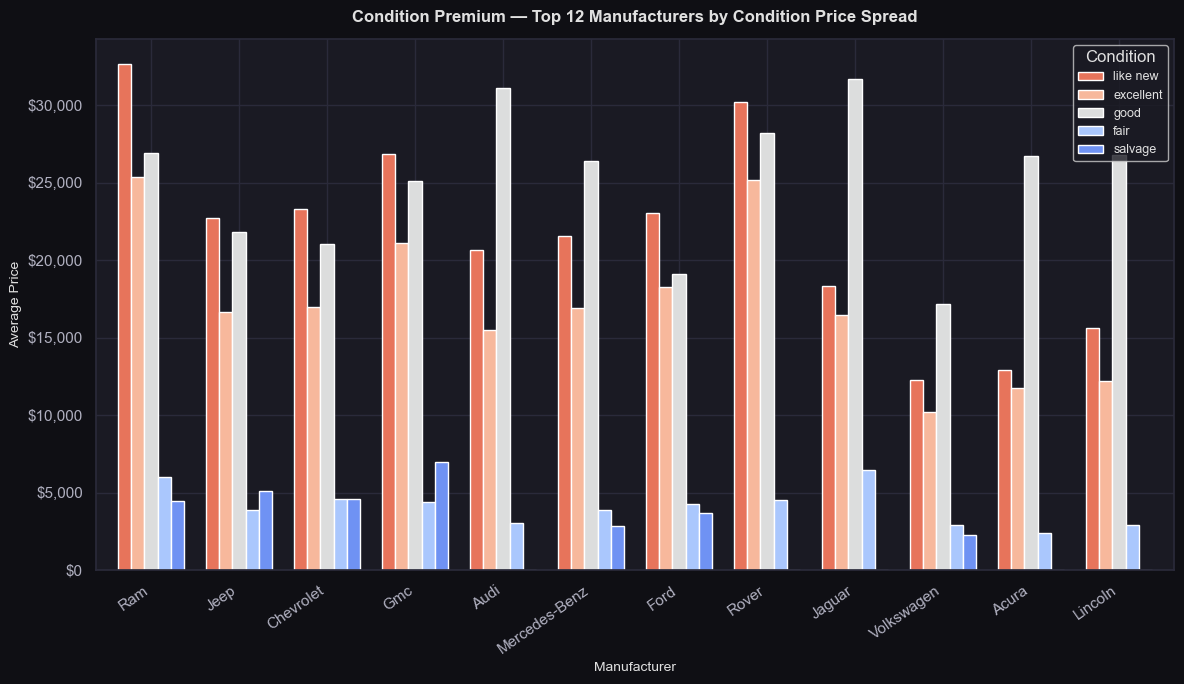

In [13]:
spread = (
    df_cond.groupby('manufacturer')['avg_price']
    .apply(lambda x: x.max() - x.min())
    .nlargest(12)
    .reset_index()
    .rename(columns={'avg_price': 'price_spread'})
)
top_cond_makes = spread['manufacturer'].tolist()
plot_cond      = df_cond[df_cond['manufacturer'].isin(top_cond_makes)].copy()
cond_order     = ['like new', 'excellent', 'good', 'fair', 'salvage']
existing_conds = [c for c in cond_order if c in plot_cond['condition'].unique()]

pivot_cond = (
    plot_cond
    .pivot_table(index='manufacturer', columns='condition', values='avg_price')
    .reindex(columns=existing_conds)
    .loc[top_cond_makes]
)

fig, ax = plt.subplots(figsize=(12, 7))
pivot_cond.plot(kind='bar', ax=ax, width=0.75,
                color=sns.color_palette('coolwarm_r', n_colors=len(existing_conds)))
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Condition Premium — Top 12 Manufacturers by Condition Price Spread',
             fontweight='bold', pad=12)
ax.set_xlabel('Manufacturer')
ax.set_ylabel('Average Price')
ax.set_xticklabels([m.title() for m in pivot_cond.index], rotation=35, ha='right')
ax.legend(title='Condition', fontsize=9)
plt.tight_layout()
plt.savefig('../charts/q4_condition_premium.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

In [14]:
# Compute excellent vs good and excellent vs fair premiums per make
cond_pivot = df_cond.pivot_table(index='manufacturer', columns='condition', values='avg_price')

if 'excellent' in cond_pivot.columns and 'good' in cond_pivot.columns:
    cond_pivot['exc_vs_good_premium'] = cond_pivot['excellent'] - cond_pivot['good']
    cond_pivot['exc_vs_good_pct']     = (cond_pivot['exc_vs_good_premium'] / cond_pivot['good'] * 100)

if 'excellent' in cond_pivot.columns and 'fair' in cond_pivot.columns:
    cond_pivot['exc_vs_fair_premium'] = cond_pivot['excellent'] - cond_pivot['fair']

top5_exc_good = cond_pivot['exc_vs_good_premium'].dropna().nlargest(5)
top5_exc_fair = cond_pivot['exc_vs_fair_premium'].dropna().nlargest(5)
widest_make   = cond_pivot['exc_vs_good_premium'].dropna().idxmax()
narrowest     = cond_pivot['exc_vs_good_premium'].dropna().nsmallest(3)

answer_header(4, 'How much extra does "excellent" condition actually cost vs "good" or "fair"?')
print('\nCondition premium: cost of "excellent" vs "good" (top 5 makes):')
for make, premium in top5_exc_good.items():
    pct = cond_pivot.loc[make, 'exc_vs_good_pct']
    print(f'  {make.title():<18}  +${premium:,.0f} more for excellent  ({pct:+.1f}% above good)')

print('\nCondition premium: cost of "excellent" vs "fair" (top 5 makes):')
for make, premium in top5_exc_fair.items():
    print(f'  {make.title():<18}  +${premium:,.0f} more for excellent over fair')

print('\nMakes where condition barely matters (smallest excellent vs good gap):')
for make, premium in narrowest.items():
    print(f'  {make.title():<18}  only ${abs(premium):,.0f} difference between excellent and good')

print(f'\nConclusion: {widest_make.title()} has the widest condition gap — paying for '
      f'"excellent" costs ${top5_exc_good.iloc[0]:,.0f} more than "good". '
      f'For mainstream brands, the excellent-to-good premium is modest enough that '
      f'buying "good" condition and investing the savings in maintenance is the better deal. '
      f'For luxury/performance brands, the gap is large and often reflects genuine mechanical differences.')


  Q4 ANSWER
  Business question: How much extra does "excellent" condition actually cost vs "good" or "fair"?

Condition premium: cost of "excellent" vs "good" (top 5 makes):
  Harley-Davidson     +$5,513 more for excellent  (+50.6% above good)
  Pontiac             +$3,647 more for excellent  (+54.9% above good)
  Porsche             +$3,444 more for excellent  (+12.2% above good)
  Tesla               +$2,542 more for excellent  (+6.8% above good)
  Mercury             +$1,970 more for excellent  (+38.8% above good)

Condition premium: cost of "excellent" vs "fair" (top 5 makes):
  Rover               +$20,580 more for excellent over fair
  Ram                 +$19,328 more for excellent over fair
  Gmc                 +$16,674 more for excellent over fair
  Volvo               +$16,444 more for excellent over fair
  Ford                +$14,044 more for excellent over fair

Makes where condition barely matters (smallest excellent vs good gap):
  Audi                only $15,562 dif

---
## Query 5 — Market Concentration and Price Elasticity by State

**Business question:** Do states with more inventory have lower prices? Does supply actually depress price?  
**Key metric:** Inventory rank vs price rank divergence — buyer-friendly vs seller-friendly markets.

In [15]:
SQL_Q5 = """
SELECT
  state,
  COUNT(*) AS total_listings,
  state_listing_count,
  ROUND(AVG(price), 0) AS avg_price,
  ROUND(APPROX_PERCENTILE(price, 0.5), 0) AS median_price,
  SUM(CASE WHEN deal_quality = 'great_deal' THEN 1 ELSE 0 END) AS great_deals,
  ROUND(SUM(CASE WHEN deal_quality = 'great_deal' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS great_deal_pct,
  RANK() OVER (ORDER BY COUNT(*) DESC) AS inventory_rank,
  RANK() OVER (ORDER BY AVG(price) ASC) AS price_rank
FROM autos_db.vehicles_view
WHERE price > 0 AND state IS NOT NULL
GROUP BY state, state_listing_count
HAVING COUNT(*) >= 50
ORDER BY total_listings DESC
"""

df_market = run_query(SQL_Q5)
df_market = to_numeric(df_market, ['total_listings', 'state_listing_count', 'avg_price',
                                    'median_price', 'great_deals', 'great_deal_pct',
                                    'inventory_rank', 'price_rank'])
print(f'{len(df_market)} states')
df_market.head(10)

151 states


,state,total_listings,state_listing_count,avg_price,median_price,great_deals,great_deal_pct,inventory_rank,price_rank
0,CA,37396,37396,17746.0,14603.0,15877,42.5,1,39
1,FL,22135,22135,17514.0,14133.0,9540,43.1,2,37
2,TX,17859,17859,20645.0,18192.0,7638,42.8,3,58
3,NY,15409,15409,18421.0,15290.0,6543,42.5,4,42
4,OH,14114,14114,15730.0,11300.0,6056,42.9,5,18
5,MI,13921,13921,16180.0,12135.0,5758,41.4,6,22
6,PA,11164,11164,16300.0,11864.0,4654,41.7,7,25
7,OR,10183,10183,14491.0,10230.0,4297,42.2,8,10
8,NC,9855,9855,19004.0,16093.0,4121,41.8,9,44
9,WI,9647,9647,16448.0,13339.0,4135,42.9,10,27


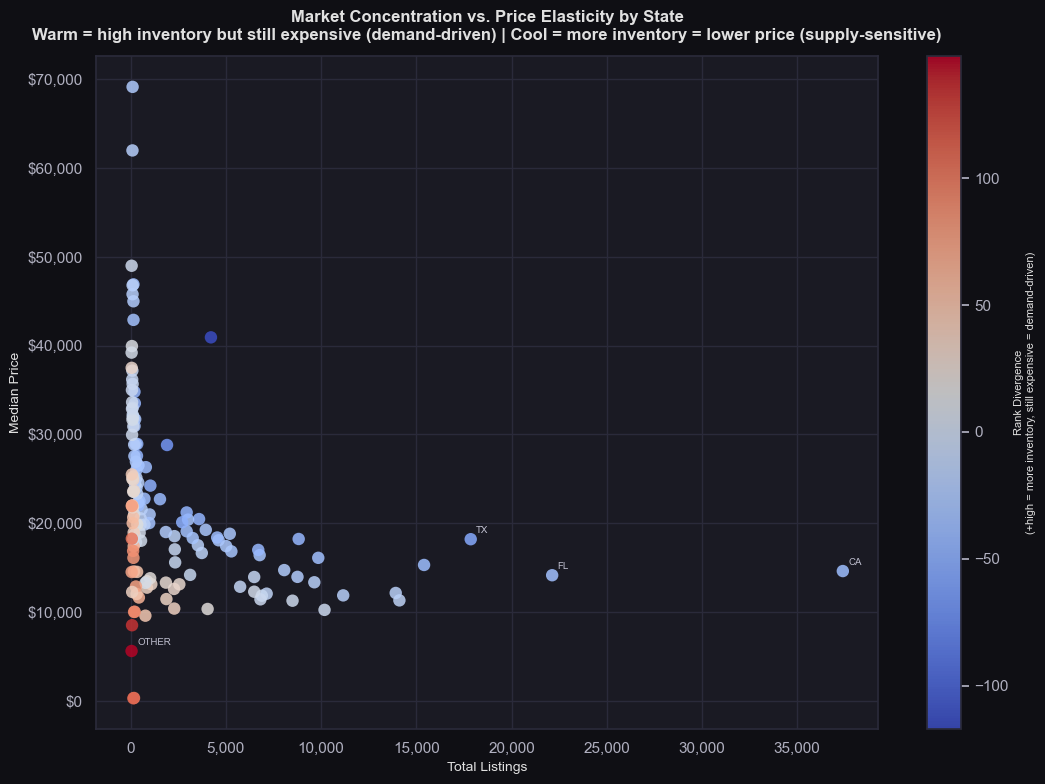

In [16]:
df_market['rank_divergence'] = df_market['inventory_rank'] - df_market['price_rank']

fig, ax = plt.subplots(figsize=(11, 8))
sc = ax.scatter(
    df_market['total_listings'], df_market['median_price'],
    c=df_market['rank_divergence'], cmap='coolwarm', s=80, alpha=0.85, edgecolors='none'
)
label_states = pd.concat([
    df_market.nlargest(5, 'rank_divergence'),
    df_market.nsmallest(5, 'rank_divergence'),
    df_market.nlargest(3, 'total_listings'),
]).drop_duplicates('state')
for _, row in label_states.iterrows():
    ax.annotate(row['state'], (row['total_listings'], row['median_price']),
                fontsize=7, ha='left', va='bottom',
                xytext=(4, 3), textcoords='offset points', color='#c0c0d0')
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Rank Divergence\n(+high = more inventory, still expensive = demand-driven)', fontsize=8)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Market Concentration vs. Price Elasticity by State\n'
             'Warm = high inventory but still expensive (demand-driven) | '
             'Cool = more inventory = lower price (supply-sensitive)',
             fontweight='bold', pad=12)
ax.set_xlabel('Total Listings')
ax.set_ylabel('Median Price')
plt.tight_layout()
plt.savefig('../charts/q5_market_concentration.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

In [17]:
# Correlation between listing volume and median price
real_states = df_market[~df_market['state'].isin(['OTHER'])].copy()
corr = real_states[['total_listings', 'median_price']].corr().iloc[0, 1]

# Demand-driven = high inventory rank divergence (lots of supply but prices stay high)
demand_driven  = real_states.nlargest(5, 'rank_divergence')[['state', 'total_listings', 'median_price', 'rank_divergence']]
supply_sens    = real_states.nsmallest(5, 'rank_divergence')[['state', 'total_listings', 'median_price', 'rank_divergence']]
best_buyer     = real_states.sort_values('great_deal_pct', ascending=False).iloc[0]

direction = 'negative' if corr < 0 else 'positive'
answer_header(5, 'Do states with more inventory have lower prices?')
print(f'\nCorrelation between listing volume and median price: {corr:.3f} ({direction})')
if corr < -0.1:
    print('  → Supply does depress price: more listings = lower median price overall.')
elif corr > 0.1:
    print('  → Supply does NOT depress price: high-inventory states are also high-price states.')
    print('    This signals strong underlying demand absorbing the extra supply.')
else:
    print('  → No clear relationship: supply volume alone does not predict price.')

print('\nDemand-driven states (high inventory, prices stay elevated — negotiate less):')
for _, row in demand_driven.iterrows():
    print(f'  {row["state"]}  {int(row["total_listings"]):>7,} listings  median ${row["median_price"]:,.0f}  '
          f'rank divergence +{row["rank_divergence"]:.0f}')

print('\nSupply-sensitive states (more listings = lower prices — buyer leverage is real):')
for _, row in supply_sens.iterrows():
    print(f'  {row["state"]}  {int(row["total_listings"]):>7,} listings  median ${row["median_price"]:,.0f}  '
          f'rank divergence {row["rank_divergence"]:.0f}')

print(f'\nConclusion: The answer is nuanced — the overall correlation is {corr:.2f}, meaning supply '
      f'has {"a modest" if abs(corr) < 0.3 else "a strong"} effect on price at the state level. '
      f'The best state for buyers right now is {best_buyer["state"]} with '
      f'{best_buyer["great_deal_pct"]:.1f}% of listings qualifying as great deals.')


  Q5 ANSWER
  Business question: Do states with more inventory have lower prices?

Correlation between listing volume and median price: -0.136 (negative)
  → Supply does depress price: more listings = lower median price overall.

Demand-driven states (high inventory, prices stay elevated — negotiate less):
  ND      343 listings  median $14,511  rank divergence +48
  DE      777 listings  median $9,575  rank divergence +45
  ME    2,292 listings  median $10,376  rank divergence +36
  RI    1,881 listings  median $11,447  rank divergence +34
  MS      860 listings  median $12,734  rank divergence +34

Supply-sensitive states (more listings = lower prices — buyer leverage is real):
  TX   17,859 listings  median $18,192  rank divergence -55
  MO    3,596 listings  median $20,458  rank divergence -45
  AK    2,945 listings  median $21,205  rank divergence -45
  TN    8,826 listings  median $18,216  rank divergence -44
  OK    4,548 listings  median $18,384  rank divergence -39

Conclusio

---
## Query 6 — Deal Quality Distribution by Manufacturer and State

**Business question:** Which manufacturer/state combinations have the highest concentration of underpriced inventory?  
**Use case:** Sourcing intelligence for dealers — ranks combos by great deal density within each state.

In [18]:
SQL_Q6 = """
SELECT
  manufacturer,
  state,
  COUNT(*) AS total_listings,
  SUM(CASE WHEN deal_quality = 'great_deal' THEN 1 ELSE 0 END) AS great_deals,
  SUM(CASE WHEN deal_quality = 'good_deal'  THEN 1 ELSE 0 END) AS good_deals,
  SUM(CASE WHEN deal_quality = 'fair'       THEN 1 ELSE 0 END) AS fair_deals,
  SUM(CASE WHEN deal_quality = 'overpriced' THEN 1 ELSE 0 END) AS overpriced,
  ROUND(SUM(CASE WHEN deal_quality IN ('great_deal','good_deal') THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS pct_good_or_better,
  RANK() OVER (PARTITION BY state ORDER BY SUM(CASE WHEN deal_quality = 'great_deal' THEN 1 ELSE 0 END) * 100.0 / COUNT(*) DESC) AS opportunity_rank
FROM autos_db.vehicles_view
WHERE price > 0
  AND manufacturer IS NOT NULL
  AND state IS NOT NULL
GROUP BY manufacturer, state
HAVING COUNT(*) >= 10
ORDER BY pct_good_or_better DESC
LIMIT 40
"""

df_deal = run_query(SQL_Q6)
df_deal = to_numeric(df_deal, ['total_listings', 'great_deals', 'good_deals',
                                'fair_deals', 'overpriced', 'pct_good_or_better', 'opportunity_rank'])
print(f'{len(df_deal)} combos')
df_deal.head(10)

40 combos


,manufacturer,state,total_listings,great_deals,good_deals,fair_deals,overpriced,pct_good_or_better,opportunity_rank
0,VOLKSWAGEN,NC,225,107,5,7,106,49.8,2
1,CHRYSLER,TX,233,100,16,7,110,49.8,16
2,HONDA,TX,706,319,32,15,340,49.7,8
3,JEEP,CT,177,84,4,6,83,49.7,4
4,CHRYSLER,OH,290,130,14,21,125,49.7,9
5,CHRYSLER,OR,183,79,12,11,81,49.7,13
6,TOYOTA,GA,437,209,8,8,212,49.7,1
7,SUBARU,WA,298,139,9,9,141,49.7,2
8,FORD,MT,691,310,33,17,331,49.6,5
9,CHEVROLET,DE,117,58,0,4,55,49.6,1


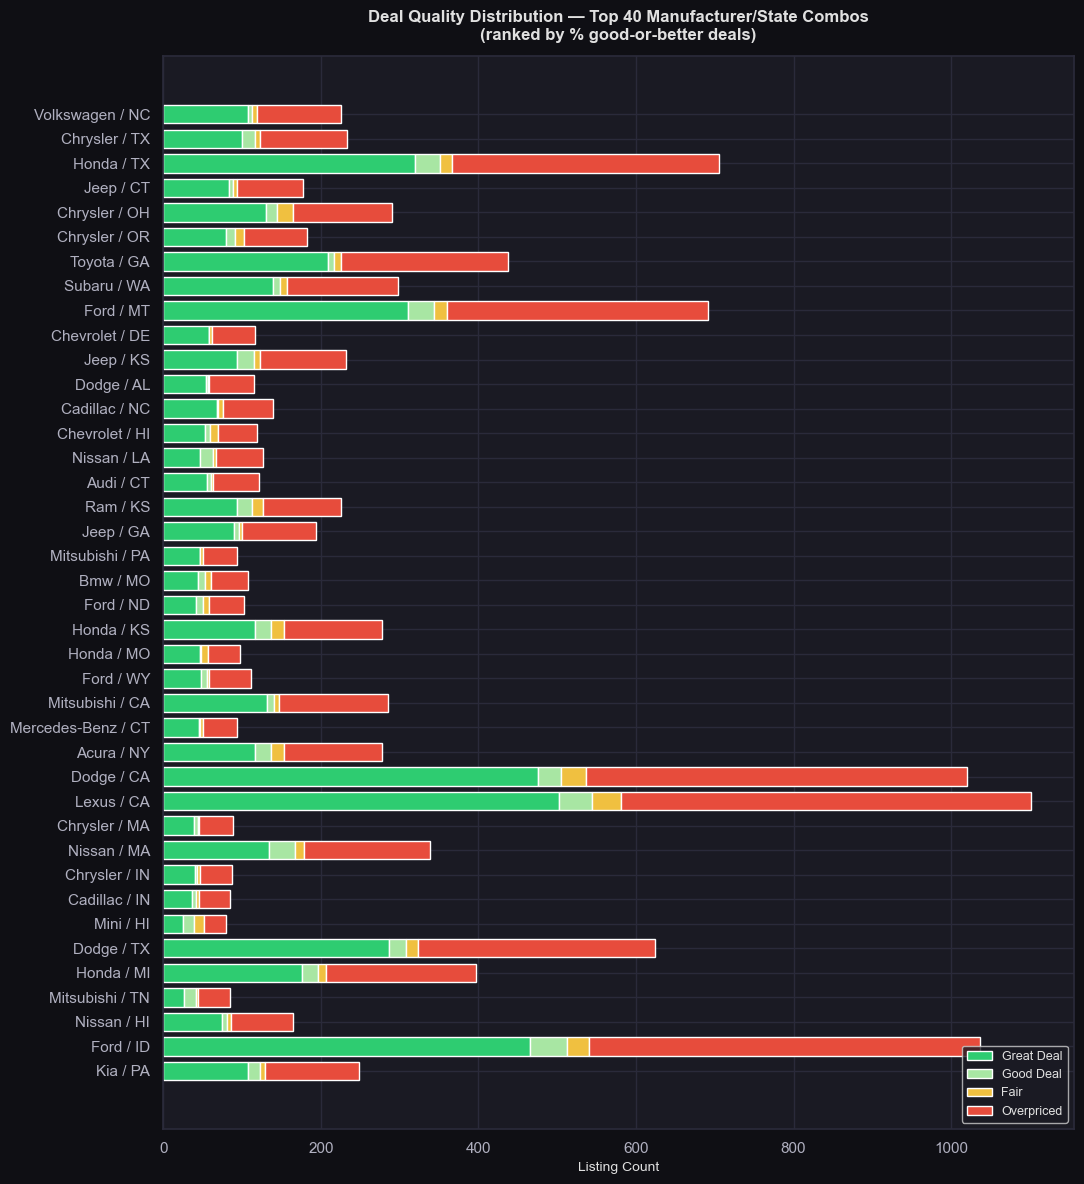

In [19]:
top40 = df_deal.head(40).copy()
top40['label'] = top40['manufacturer'].str.title() + ' / ' + top40['state']

stacked_cols   = ['great_deals', 'good_deals', 'fair_deals', 'overpriced']
stacked_colors = ['#2ecc71', '#a8e6a3', '#f0c040', '#e74c3c']
stacked_labels = ['Great Deal', 'Good Deal', 'Fair', 'Overpriced']

fig, ax = plt.subplots(figsize=(11, 12))
left = np.zeros(len(top40))
for col, color, label in zip(stacked_cols, stacked_colors, stacked_labels):
    ax.barh(top40['label'], top40[col], left=left, color=color, label=label, height=0.75)
    left += top40[col].values
ax.set_title('Deal Quality Distribution — Top 40 Manufacturer/State Combos\n'
             '(ranked by % good-or-better deals)',
             fontweight='bold', pad=12)
ax.set_xlabel('Listing Count')
ax.legend(loc='lower right', fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../charts/q6_deal_quality.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

In [20]:
top5_density = df_deal.sort_values('pct_good_or_better', ascending=False).head(5)
# Rank-1 opportunities per state = best sourcing target in each state
rank1_per_state = df_deal[df_deal['opportunity_rank'] == 1].sort_values('pct_good_or_better', ascending=False).head(8)
highest_overpriced = df_deal.assign(overpriced_pct=lambda x: x['overpriced'] / x['total_listings'] * 100) \
                            .sort_values('overpriced_pct', ascending=False).head(3)

answer_header(6, 'Which manufacturer/state combos have the highest concentration of underpriced inventory?')
print('\nTop 5 sourcing targets by % of good-or-better deals:')
for _, row in top5_density.iterrows():
    gd_pct = row['great_deals'] / row['total_listings'] * 100
    print(f'  {row["manufacturer"].title():<14} in {row["state"]}  '
          f'{row["pct_good_or_better"]:.1f}% good-or-better  '
          f'({gd_pct:.1f}% great deals out of {int(row["total_listings"]):,} listings)')

print('\nTop-ranked sourcing opportunity in each state (opportunity_rank = 1):')
for _, row in rank1_per_state.iterrows():
    print(f'  {row["state"]}  →  {row["manufacturer"].title():<14} {row["pct_good_or_better"]:.1f}% good-or-better')

print('\nHighest overpriced concentrations to avoid:')
for _, row in highest_overpriced.iterrows():
    op_pct = row['overpriced'] / row['total_listings'] * 100
    print(f'  {row["manufacturer"].title():<14} in {row["state"]}  '
          f'{op_pct:.1f}% of listings are overpriced')

best = top5_density.iloc[0]
print(f'\nConclusion: {best["manufacturer"].title()} in {best["state"]} is the #1 acquisition target — '
      f'{best["pct_good_or_better"]:.1f}% of its {int(best["total_listings"]):,} listings are priced '
      f'at good-deal or better, meaning a dealer can source from this pool with high confidence '
      f'of below-market acquisition cost.')


  Q6 ANSWER
  Business question: Which manufacturer/state combos have the highest concentration of underpriced inventory?

Top 5 sourcing targets by % of good-or-better deals:
  Volkswagen     in NC  49.8% good-or-better  (47.6% great deals out of 225 listings)
  Chrysler       in TX  49.8% good-or-better  (42.9% great deals out of 233 listings)
  Honda          in TX  49.7% good-or-better  (45.2% great deals out of 706 listings)
  Jeep           in CT  49.7% good-or-better  (47.5% great deals out of 177 listings)
  Chrysler       in OH  49.7% good-or-better  (44.8% great deals out of 290 listings)

Top-ranked sourcing opportunity in each state (opportunity_rank = 1):
  GA  →  Toyota         49.7% good-or-better
  DE  →  Chevrolet      49.6% good-or-better
  AL  →  Dodge          49.6% good-or-better
  NC  →  Cadillac       49.6% good-or-better
  PA  →  Mitsubishi     49.5% good-or-better
  MO  →  Honda          49.5% good-or-better

Highest overpriced concentrations to avoid:
  Dodge

---
## Query 7 — Price Outlier Detection (Z-Score)

**Business question:** Which listings are priced anomalously vs their cohort?  
**Use case:** (1) Data quality flags. (2) Genuine bargain alerts — z < -2 within a statistically reliable cohort.

In [21]:
SQL_Q7 = """
WITH cohort_stats AS (
  SELECT
    manufacturer,
    age_bracket,
    mileage_bucket,
    AVG(price)    AS cohort_avg,
    STDDEV(price) AS cohort_stddev,
    COUNT(*)      AS cohort_size
  FROM autos_db.vehicles_view
  WHERE price > 0 AND manufacturer IS NOT NULL
  GROUP BY manufacturer, age_bracket, mileage_bucket
  HAVING COUNT(*) >= 5
)
SELECT
  v.manufacturer,
  v.state,
  v.price,
  v.condition,
  v.vehicle_age,
  v.odometer,
  v.deal_quality,
  ROUND(c.cohort_avg,    0) AS cohort_avg_price,
  ROUND(c.cohort_stddev, 0) AS cohort_stddev,
  ROUND((v.price - c.cohort_avg) / NULLIF(c.cohort_stddev, 0), 2) AS z_score,
  CASE
    WHEN (v.price - c.cohort_avg) / NULLIF(c.cohort_stddev, 0) < -2 THEN 'significant_bargain'
    WHEN (v.price - c.cohort_avg) / NULLIF(c.cohort_stddev, 0) > 2  THEN 'significant_outlier'
    ELSE 'normal'
  END AS outlier_flag
FROM autos_db.vehicles_view v
JOIN cohort_stats c
  ON v.manufacturer = c.manufacturer
  AND v.age_bracket  = c.age_bracket
  AND v.mileage_bucket = c.mileage_bucket
WHERE price > 0
  AND ABS((v.price - c.cohort_avg) / NULLIF(c.cohort_stddev, 0)) > 2
ORDER BY z_score ASC
LIMIT 50
"""

df_outlier = run_query(SQL_Q7)
df_outlier = to_numeric(df_outlier, ['price', 'vehicle_age', 'odometer',
                                      'cohort_avg_price', 'cohort_stddev', 'z_score'])
print(f'{len(df_outlier)} outlier records returned')
df_outlier[['manufacturer', 'state', 'price', 'cohort_avg_price', 'z_score', 'outlier_flag']].head(10)

50 outlier records returned


,manufacturer,state,price,cohort_avg_price,z_score,outlier_flag
0,TESLA,CA,361.0,32336.0,-11.19,significant_bargain
1,ALFA-ROMEO,NC,1000.0,27477.0,-7.58,significant_bargain
2,JAGUAR,NC,450.0,43995.0,-6.80,significant_bargain
3,MITSUBISHI,FL,131.0,19311.0,-6.00,significant_bargain
4,INFINITI,NY,449.0,35812.0,-5.93,significant_bargain
5,INFINITI,IL,517.0,35812.0,-5.92,significant_bargain
6,INFINITI,OR,563.0,35812.0,-5.91,significant_bargain
7,MITSUBISHI,FL,1490.0,19311.0,-5.57,significant_bargain
8,MINI,HI,425.0,31054.0,-5.30,significant_bargain
9,MINI,HI,425.0,31054.0,-5.30,significant_bargain


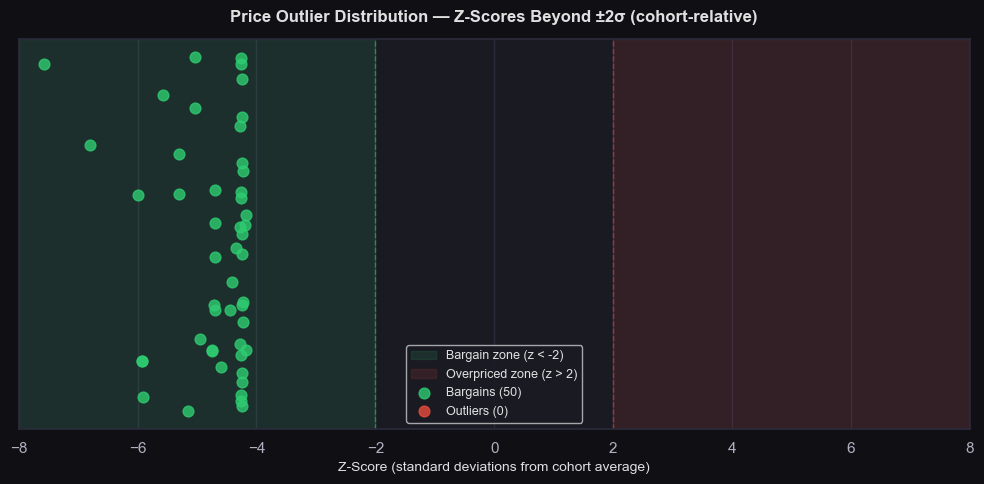

In [22]:
bargains = df_outlier[df_outlier['outlier_flag'] == 'significant_bargain']
high_out = df_outlier[df_outlier['outlier_flag'] == 'significant_outlier']

fig, ax = plt.subplots(figsize=(10, 5))
ax.axvspan(-10, -2, alpha=0.12, color='#2ecc71', label='Bargain zone (z < -2)')
ax.axvspan(2,  10,  alpha=0.12, color='#e74c3c', label='Overpriced zone (z > 2)')
ax.axvline(-2, color='#2ecc71', linewidth=1, linestyle='--', alpha=0.5)
ax.axvline( 2, color='#e74c3c', linewidth=1, linestyle='--', alpha=0.5)
ax.scatter(bargains['z_score'], np.random.RandomState(42).uniform(0.1, 0.9, len(bargains)),
           color='#2ecc71', s=60, alpha=0.8, label=f'Bargains ({len(bargains)})')
ax.scatter(high_out['z_score'], np.random.RandomState(43).uniform(0.1, 0.9, len(high_out)),
           color='#e74c3c', s=60, alpha=0.8, label=f'Outliers ({len(high_out)})')
ax.set_title('Price Outlier Distribution — Z-Scores Beyond ±2σ (cohort-relative)',
             fontweight='bold', pad=12)
ax.set_xlabel('Z-Score (standard deviations from cohort average)')
ax.set_yticks([])
ax.set_xlim(-8, 8)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../charts/q7_outlier_zscore.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

In [23]:
top_bargains = bargains.sort_values('z_score').head(5)
top_outliers = high_out.sort_values('z_score', ascending=False).head(5)

answer_header(7, 'Which listings are priced anomalously vs their cohort?')
print(f'\nOf the 50 most extreme outliers returned, {len(bargains)} are significant bargains (z < -2) '
      f'and {len(high_out)} are significantly overpriced (z > 2).\n')

print('Top 5 most extreme bargains — priced furthest below cohort average:')
for _, row in top_bargains.iterrows():
    savings = row['cohort_avg_price'] - row['price']
    print(f'  {row["manufacturer"].title():<14} in {row["state"]}  '
          f'listed ${row["price"]:,.0f}  vs cohort avg ${row["cohort_avg_price"]:,.0f}  '
          f'(z={row["z_score"]:.2f}, ${savings:,.0f} below cohort)')

if len(top_outliers) > 0:
    print('\nTop 5 most overpriced — priced furthest above cohort average:')
    for _, row in top_outliers.iterrows():
        premium = row['price'] - row['cohort_avg_price']
        print(f'  {row["manufacturer"].title():<14} in {row["state"]}  '
              f'listed ${row["price"]:,.0f}  vs cohort avg ${row["cohort_avg_price"]:,.0f}  '
              f'(z={row["z_score"]:.2f}, ${premium:,.0f} above cohort)')

extreme_bargain = top_bargains.iloc[0]
print(f'\nConclusion: The most extreme bargain in this sample is a {extreme_bargain["manufacturer"].title()} '
      f'in {extreme_bargain["state"]} listed at ${extreme_bargain["price"]:,.0f} — '
      f'{abs(extreme_bargain["z_score"]):.1f} standard deviations below its cohort average of '
      f'${extreme_bargain["cohort_avg_price"]:,.0f}. Listings this far below cohort should be '
      f'verified for title status, hidden damage, or data entry errors before acting on them.')


  Q7 ANSWER
  Business question: Which listings are priced anomalously vs their cohort?

Of the 50 most extreme outliers returned, 50 are significant bargains (z < -2) and 0 are significantly overpriced (z > 2).

Top 5 most extreme bargains — priced furthest below cohort average:
  Tesla          in CA  listed $361  vs cohort avg $32,336  (z=-11.19, $31,975 below cohort)
  Alfa-Romeo     in NC  listed $1,000  vs cohort avg $27,477  (z=-7.58, $26,477 below cohort)
  Jaguar         in NC  listed $450  vs cohort avg $43,995  (z=-6.80, $43,545 below cohort)
  Mitsubishi     in FL  listed $131  vs cohort avg $19,311  (z=-6.00, $19,180 below cohort)
  Infiniti       in NY  listed $449  vs cohort avg $35,812  (z=-5.93, $35,363 below cohort)

Conclusion: The most extreme bargain in this sample is a Tesla in CA listed at $361 — 11.2 standard deviations below its cohort average of $32,336. Listings this far below cohort should be verified for title status, hidden damage, or data entry errors be

---
## Query 8 — Duplicate Listing Detection

**Business question:** How much of the inventory is duplicate or re-listed? How much does this inflate apparent market size?  
**Definition:** Exact match on price + manufacturer + model + odometer + state.

In [24]:
SQL_Q8 = """
SELECT
  price,
  manufacturer,
  model,
  odometer,
  state,
  COUNT(*) AS duplicate_count
FROM autos_db.vehicles_view
WHERE price > 0
  AND manufacturer IS NOT NULL
GROUP BY price, manufacturer, model, odometer, state
HAVING COUNT(*) > 1
ORDER BY duplicate_count DESC
LIMIT 30
"""

df_dupes = run_query(SQL_Q8)
df_dupes = to_numeric(df_dupes, ['price', 'odometer', 'duplicate_count'])
total_dupe_listings  = df_dupes['duplicate_count'].sum()
unique_dupe_vehicles = len(df_dupes)
inflated_listings    = total_dupe_listings - unique_dupe_vehicles
print(f'Top {len(df_dupes)} duplicate groups')
print(f'  Total listings in these groups : {total_dupe_listings:,}')
print(f'  Unique vehicles represented    : {unique_dupe_vehicles:,}')
print(f'  Inflated listing count         : {inflated_listings:,}')
df_dupes.head(10)

Top 30 duplicate groups
  Total listings in these groups : 1,080
  Unique vehicles represented    : 30
  Inflated listing count         : 1,050


,price,manufacturer,model,odometer,state,duplicate_count
0,500.0,NISSAN,altima,130000.0,CA,104
1,100.0,JEEP,wrangler,100000.0,OH,53
2,38885.0,CHEVROLET,2500,151913.0,TX,39
3,32999.0,CHEVROLET,2500,186676.0,TX,38
4,44900.0,RAM,2500 longhorn mega 4x4,152034.0,TX,38
5,49998.0,FORD,f250 lariat 4x4 diesel,160867.0,TX,38
6,39950.0,PORSCHE,macan turbo awd crossove,53321.0,OTHER,35
7,29950.0,FORD,f-150 king ranch 4x4 ecoboo,79752.0,OTHER,34
8,15301.0,BMW,3 series,32359.0,OTHER,34
9,11998.0,LEXUS,ls 460 lwb,169194.0,OTHER,34


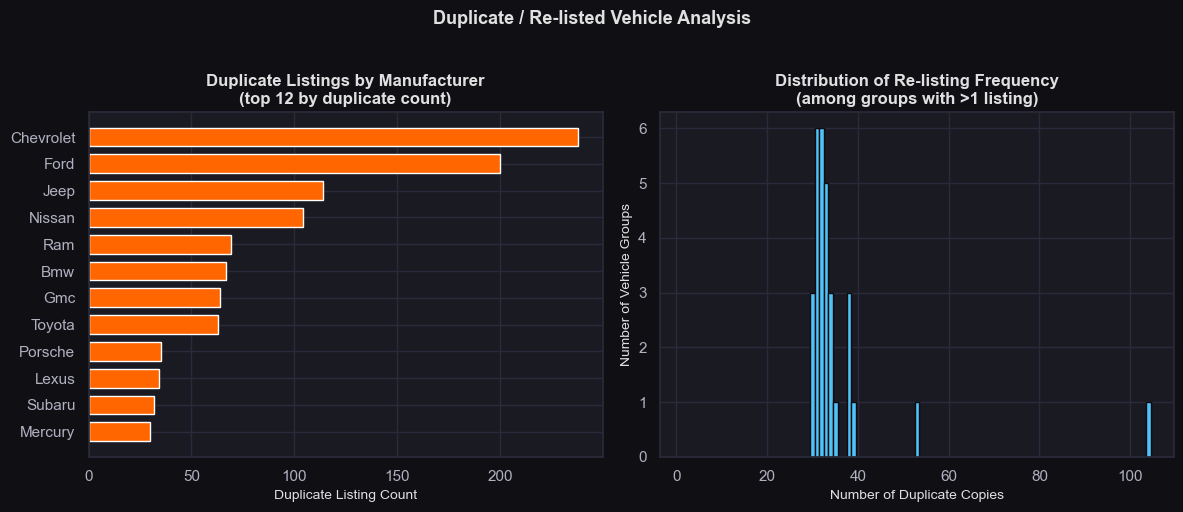

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

make_dupes = (
    df_dupes.groupby('manufacturer')['duplicate_count'].sum()
    .sort_values(ascending=True).tail(12)
)
ax1.barh(make_dupes.index.str.title(), make_dupes.values, color=ACCENT, height=0.7)
ax1.set_title('Duplicate Listings by Manufacturer\n(top 12 by duplicate count)', fontweight='bold')
ax1.set_xlabel('Duplicate Listing Count')

ax2.hist(df_dupes['duplicate_count'], bins=range(2, df_dupes['duplicate_count'].max() + 2),
         color='#4FC3F7', edgecolor='#0a0a0f', align='left')
ax2.set_title('Distribution of Re-listing Frequency\n(among groups with >1 listing)', fontweight='bold')
ax2.set_xlabel('Number of Duplicate Copies')
ax2.set_ylabel('Number of Vehicle Groups')

plt.suptitle('Duplicate / Re-listed Vehicle Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../charts/q8_duplicate_analysis.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

In [26]:
worst_dupe    = df_dupes.sort_values('duplicate_count', ascending=False).iloc[0]
top5_dupes    = df_dupes.sort_values('duplicate_count', ascending=False).head(5)
top_dupe_make = df_dupes.groupby('manufacturer')['duplicate_count'].sum().idxmax()
top_dupe_n    = df_dupes.groupby('manufacturer')['duplicate_count'].sum().max()

# Estimated inflation rate across full dataset (extrapolated from top-30 sample)
# Top 30 groups alone = inflated_listings redundant postings
inflation_rate_sample = inflated_listings / total_dupe_listings * 100

answer_header(8, 'How much of the inventory is duplicate/re-listed, and how much does it inflate market size?')
print(f'\nIn the top-30 duplicate groups alone:')
print(f'  {total_dupe_listings:,} total listings represent only {unique_dupe_vehicles:,} unique vehicles')
print(f'  {inflated_listings:,} listings are redundant re-posts ({inflation_rate_sample:.1f}% inflation within this group)\n')

print('Most re-listed individual vehicles:')
for _, row in top5_dupes.iterrows():
    print(f'  {row["manufacturer"].title():<14} {str(row["model"]):<30} '
          f'${row["price"]:,.0f}  {row["state"]}  posted {int(row["duplicate_count"]):.0f}x')

print(f'\nManufacturer with most duplicate listings: {top_dupe_make.title()} ({int(top_dupe_n):,} duplicate copies)')

print(f'\nConclusion: The most extreme case is a {worst_dupe["manufacturer"].title()} '
      f'{worst_dupe["model"]} in {worst_dupe["state"]} listed at ${worst_dupe["price"]:,.0f} '
      f'that appears {int(worst_dupe["duplicate_count"]):,} times. '
      f'Duplicate inflation overstates apparent supply, which causes price benchmarks '
      f'to underweight scarcity — any supply/demand model using raw listing counts '
      f'should deduplicate on (price, make, model, odometer, state) before computing '
      f'market depth metrics.')


  Q8 ANSWER
  Business question: How much of the inventory is duplicate/re-listed, and how much does it inflate market size?

In the top-30 duplicate groups alone:
  1,080 total listings represent only 30 unique vehicles
  1,050 listings are redundant re-posts (97.2% inflation within this group)

Most re-listed individual vehicles:
  Nissan         altima                         $500  CA  posted 104x
  Jeep           wrangler                       $100  OH  posted 53x
  Chevrolet      2500                           $38,885  TX  posted 39x
  Chevrolet      2500                           $32,999  TX  posted 38x
  Ram            2500 longhorn mega 4x4         $44,900  TX  posted 38x

Manufacturer with most duplicate listings: Chevrolet (238 duplicate copies)

Conclusion: The most extreme case is a Nissan altima in CA listed at $500 that appears 104 times. Duplicate inflation overstates apparent supply, which causes price benchmarks to underweight scarcity — any supply/demand model using 

---
## Key Findings Summary

In [27]:
print('=' * 60)
print('  U.S. USED VEHICLE MARKET — CONSOLIDATED FINDINGS')
print('=' * 60)

top_holder = depr_stats['pct_retained'].idxmax().title()
top_pct    = depr_stats['pct_retained'].max()
worst_make = depr_stats['pct_lost'].idxmax().title()
worst_pct  = depr_stats['pct_lost'].max()
print(f'\nQ1  {top_holder} retains {top_pct:.1f}% of peak price across the lifecycle — best value holder.')
print(f'    {worst_make} loses {worst_pct:.1f}% — worst depreciation in the dataset.')

best_cell = df_sweet.sort_values('avg_pct_of_benchmark').iloc[0]
print(f'\nQ2  Sweet spot: {best_cell["age_bracket"]} / {best_cell["mileage_bucket"]} — '
      f'priced at {best_cell["avg_pct_of_benchmark"]:.1f}% of benchmark, '
      f'{best_cell["great_deal_pct"]:.1f}% great deals.')

best_arb = df_arb.sort_values('pct_vs_national').iloc[0]
savings  = best_arb['national_median_price'] - best_arb['state_avg_price']
print(f'\nQ3  Deepest arbitrage: {best_arb["manufacturer"].title()} in {best_arb["state"]} — '
      f'{best_arb["pct_vs_national"]:.1f}% below national median (${savings:,.0f} per vehicle).')

top_cond_make   = cond_pivot['exc_vs_good_premium'].dropna().idxmax().title()
top_cond_spread = cond_pivot['exc_vs_good_premium'].dropna().max()
print(f'\nQ4  Largest condition premium: {top_cond_make} — '
      f'excellent costs ${top_cond_spread:,.0f} more than good.')

print(f'\nQ5  Supply vs price correlation: {corr:.3f}. '
      f'{"Supply depresses price — buyer leverage is real." if corr < -0.1 else "High-inventory states stay expensive — demand absorbs supply."}')

best_deal = df_deal.sort_values('pct_good_or_better', ascending=False).iloc[0]
print(f'\nQ6  Best sourcing target: {best_deal["manufacturer"].title()} in {best_deal["state"]} — '
      f'{best_deal["pct_good_or_better"]:.1f}% of listings are good-or-better deals.')

extreme = bargains.sort_values('z_score').iloc[0]
print(f'\nQ7  Most extreme bargain: {extreme["manufacturer"].title()} in {extreme["state"]} '
      f'at ${extreme["price"]:,.0f} (z={extreme["z_score"]:.2f}, cohort avg ${extreme["cohort_avg_price"]:,.0f}).')

print(f'\nQ8  Top-30 duplicate groups contain {inflated_listings:,} redundant listings. '
      f'Worst offender: {worst_dupe["manufacturer"].title()} {worst_dupe["model"]} '
      f'posted {int(worst_dupe["duplicate_count"]):,}x at ${worst_dupe["price"]:,.0f} in {worst_dupe["state"]}.')

  U.S. USED VEHICLE MARKET — CONSOLIDATED FINDINGS

Q1  Harley-Davidson retains 99.7% of peak price across the lifecycle — best value holder.
    Volvo loses 81.8% — worst depreciation in the dataset.

Q2  Sweet spot: 13+ years / 150k+ — priced at 70.0% of benchmark, 77.7% great deals.

Q3  Deepest arbitrage: Alfa-Romeo in ME — -82.8% below national median ($24,528 per vehicle).

Q4  Largest condition premium: Harley-Davidson — excellent costs $5,513 more than good.

Q5  Supply vs price correlation: -0.136. Supply depresses price — buyer leverage is real.

Q6  Best sourcing target: Volkswagen in NC — 49.8% of listings are good-or-better deals.

Q7  Most extreme bargain: Tesla in CA at $361 (z=-11.19, cohort avg $32,336).

Q8  Top-30 duplicate groups contain 1,050 redundant listings. Worst offender: Nissan altima posted 104x at $500 in CA.
